# 03 — Análisis de Sentimiento

## Objetivo
Clasificar cada comentario como positivo, negativo o neutral utilizando un modelo BERT (pysentimiento) entrenado en redes sociales, y comparar los resultados con una línea base basada en lexicones.

## Modelos

| Idioma | Modelo principal | Línea base |
|--------|-----------------|------------|
| Español | `pysentimiento` (BERT fine-tuned en español) | Lexicón de polaridad (NRC-EmoLex ES) |
| Inglés | `pysentimiento` (RoBERTa fine-tuned en Twitter) | VADER |

**¿Por qué pysentimiento para ambos idiomas?**
pysentimiento 0.7+ ofrece modelos para ES y EN bajo una misma API. Esto evita mantener rutas de carga separadas (como se hacía antes con HuggingFace RoBERTa como modelo EN separado) y permite usar inferencia por lotes (batch inference) de forma consistente.

**Línea base ES**: Lexicón de polaridad. VADER es solo inglés, y TextBlob-es no tiene mantenimiento. Un contador de palabras positivas/negativas es transparente y suficiente para comparación.

## Valor para el negocio
La clasificación de sentimiento convierte miles de comentarios crudos en un KPI único: *¿Qué porcentaje de aficionados se siente positivamente sobre nuestro equipo hoy?* Esta es la métrica principal que el dashboard mostrará a lo largo del tiempo.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.sentiment import (
    predict_sentiment_bert,
    predict_sentiment_baseline,
    apply_sentiment_pipeline,
    apply_sentiment_incremental,
)
from src.config import PROCESSED_DIR
from src.utils import load_dataframe, save_dataframe, setup_logger

logger = setup_logger(__name__)
print(f"Project root: {project_root}")

Project root: /home/runner/work/An-lisis-de-sentimiento-de-los-aficionadosMundial-2026-/An-lisis-de-sentimiento-de-los-aficionadosMundial-2026-


---

### 1. Cargar datos preprocesados

In [2]:
# Try multiple possible paths
candidates = [
    PROCESSED_DIR / "comentarios_limpios" / "comentarios_limpios.parquet",
    PROCESSED_DIR / "preprocessed.parquet",
]
df = None
for p in candidates:
    if p.exists():
        df = load_dataframe(str(p))
        print(f"Datos cargados desde: {p}")
        break

if df is None or df.empty:
    print("=" * 60)
    print("  NO HAY DATOS PREPROCESADOS")
    print("  Ejecuta primero el notebook 02 — Limpieza y Preprocesamiento")
    print("=" * 60)
else:
    print(f"Comentarios cargados: {len(df)}")
    print(f"Columnas: {list(df.columns)}")
    display(df[['text_clean', 'language', 'teams']].head(3))

Datos cargados desde: /home/runner/work/An-lisis-de-sentimiento-de-los-aficionadosMundial-2026-/An-lisis-de-sentimiento-de-los-aficionadosMundial-2026-/data/processed/comentarios_limpios/comentarios_limpios.parquet
Comentarios cargados: 55159
Columnas: ['comment_id', 'video_id', 'parent_id', 'text', 'author', 'published_at', 'like_count', 'total_reply_count', 'source', 'collected_at', 'text_hash', 'teams', 'video_title', 'video_published_at', 'search_team', 'search_opponent', 'match_date', 'is_spam', 'text_clean', 'emojis', 'n_emojis', 'language', 'lang_confidence', 'tokens']


,text_clean,language,teams
0,People forget this was the same way Morocco pl...,en,Brazil
1,People also forget that Brazil has been chokin...,en,Brazil
2,better than Italy,en,Brazil


---

### 2. Aplicar pipeline de sentimiento (incremental)

Usamos `apply_sentiment_incremental` para ejecutar el modelo BERT (pysentimiento) **solo sobre comentarios nuevos** que no tengan sentimiento previamente calculado. Los resultados existentes se cargan desde `comentarios_sentimiento.parquet`, se identifican los `comment_id` nuevos, y se hace inferencia por lotes (batch) agrupada por idioma únicamente sobre el delta. Al final se fusionan los datos nuevos con los existentes.

In [3]:
if df is not None and not df.empty:
    sentiment_dir = PROCESSED_DIR / "comentarios_sentimiento"
    existing_path = sentiment_dir / "comentarios_sentimiento.parquet"
    
    df = apply_sentiment_incremental(
        df_new=df,
        existing_path=existing_path,
        show_progress=True,
    )
    
    print(f"\nDimensiones: {df.shape}")
    display(df[['text_clean', 'language', 'sentiment_bert', 'sentiment_baseline']].head(10))

2026-06-27 11:23:55 | src.sentiment | INFO     | Loaded 49635 existing sentiment results from /home/runner/work/An-lisis-de-sentimiento-de-los-aficionadosMundial-2026-/An-lisis-de-sentimiento-de-los-aficionadosMundial-2026-/data/processed/comentarios_sentimiento/comentarios_sentimiento.parquet


2026-06-27 11:23:55 | src.sentiment | INFO     | 49633 comments already have sentiment labels, running BERT on 5524 new comments only.


Sentiment analysis:   0%|          | 0/5524 [00:00<?, ?comments/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

2026-06-27 11:24:00 | src.sentiment | INFO     | pysentimiento analyzer loaded for lang=es


...

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/runner/nltk_data...


2026-06-27 11:32:01 | src.sentiment | INFO     | Sentiment pipeline complete: 5524 comments


2026-06-27 11:32:01 | src.sentiment | INFO     | Incremental merge complete — total: 55159 comments.



Dimensiones: (55159, 27)


,text_clean,language,sentiment_bert,sentiment_baseline
0,People forget this was the same way Morocco pl...,en,NEU,NEU
1,People also forget that Brazil has been chokin...,en,NEG,NEU
2,better than Italy,en,NEU,NEU
3,Return of the moors lol,en,NEU,NEU
4,not by much. It’s much easier to qualify when ...,en,NEU,NEU
5,hahaha these is the 0 futbol knowledge brain. ...,en,NEG,NEU
6,Brazil spent more energy on their player intro...,en,NEG,NEU
7,lol...,es,NEU,NEU
8,Absolutely. I saw at least 10 times they just ...,en,NEU,NEU
9,Reminded me of the 2014 semifinal against Germ...,en,NEU,NEU


---

### 3. Distribución de sentimiento

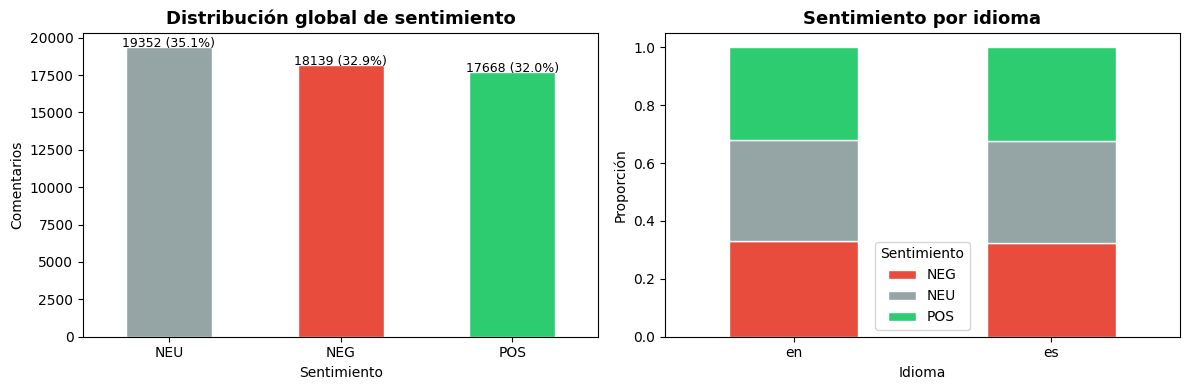


Distribución numérica:
sentiment_bert
NEU    19352
NEG    18139
POS    17668


In [4]:
if df is not None and not df.empty and 'sentiment_bert' in df.columns:
    dist = df['sentiment_bert'].value_counts()
    colors = {'POS': '#2ecc71', 'NEU': '#95a5a6', 'NEG': '#e74c3c'}
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Overall distribution
    ax = axes[0]
    bars = dist.plot(kind='bar', ax=ax, color=[colors.get(l, '#999') for l in dist.index], edgecolor='white')
    ax.set_title('Distribución global de sentimiento', fontsize=13, fontweight='bold')
    ax.set_xlabel('Sentimiento')
    ax.set_ylabel('Comentarios')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    for bar, val in zip(bars.patches, dist.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{val} ({val/len(df)*100:.1f}%)', ha='center', fontsize=9)
    
    # By language
    ax = axes[1]
    if 'language' in df.columns:
        ct = pd.crosstab(df['language'], df['sentiment_bert'], normalize='index')
        ct.plot(kind='bar', stacked=True, ax=ax, color=[colors.get(l, '#999') for l in ct.columns], edgecolor='white')
        ax.set_title('Sentimiento por idioma', fontsize=13, fontweight='bold')
        ax.set_xlabel('Idioma')
        ax.set_ylabel('Proporción')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
        ax.legend(title='Sentimiento')
    
    plt.tight_layout()
    plt.show()
    
    print("\nDistribución numérica:")
    print(dist.to_string())

#### Sentimiento por equipo (search_team)

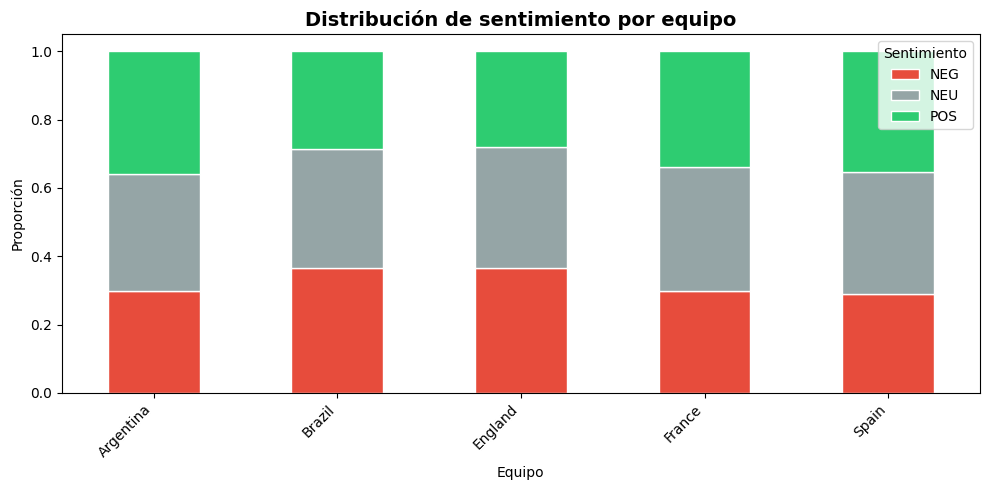

sentiment_bert,NEG,NEU,POS
search_team,,,
Argentina,0.298,0.342,0.360
Brazil,0.366,0.347,0.287
England,0.367,0.353,0.281
France,0.300,0.362,0.338
Spain,0.288,0.358,0.354


In [5]:
if df is not None and not df.empty and 'sentiment_bert' in df.columns and 'search_team' in df.columns:
    team_sent = (
        df.groupby('search_team')['sentiment_bert']
        .value_counts(normalize=True)
        .unstack()
        .fillna(0)
    )
    team_sent = team_sent[sorted(team_sent.columns)]  # POS, NEU, NEG order
    
    fig, ax = plt.subplots(figsize=(10, 5))
    team_sent.plot(
        kind='bar', stacked=True, ax=ax,
        color=[colors.get(l, '#999') for l in team_sent.columns],
        edgecolor='white',
    )
    ax.set_title('Distribución de sentimiento por equipo', fontsize=14, fontweight='bold')
    ax.set_xlabel('Equipo')
    ax.set_ylabel('Proporción')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.legend(title='Sentimiento')
    plt.tight_layout()
    plt.show()
    
    display(team_sent.round(3))

---

### 4. Comparación: BERT vs Línea base

Comparamos las predicciones del modelo BERT con la línea base en todo el dataset (sin etiquetas manuales — solo concordancia entre modelos).

In [6]:
if df is not None and not df.empty and 'sentiment_bert' in df.columns and 'sentiment_baseline' in df.columns:
    agreement = (df['sentiment_bert'] == df['sentiment_baseline']).mean()
    print(f"Concordancia BERT ↔ Baseline: {agreement:.1%}")
    
    # Crosstab
    cross = pd.crosstab(
        df['sentiment_bert'],
        df['sentiment_baseline'],
        margins=True,
        margins_name='Total',
    )
    print("\nTabla cruzada (BERT filas × Baseline columnas):")
    display(cross)
    
    # Normalized by row
    cross_norm = pd.crosstab(
        df['sentiment_bert'],
        df['sentiment_baseline'],
        normalize='index',
    )
    print("\nConcordancia relativa por clase BERT:")
    display(cross_norm.round(3))

Concordancia BERT ↔ Baseline: 49.9%

Tabla cruzada (BERT filas × Baseline columnas):


sentiment_baseline,NEG,NEU,POS,Total
sentiment_bert,,,,
NEG,3004,13007,2128,18139
NEU,597,15930,2825,19352
POS,244,8818,8606,17668
Total,3845,37755,13559,55159



Concordancia relativa por clase BERT:


sentiment_baseline,NEG,NEU,POS
sentiment_bert,,,
NEG,0.166,0.717,0.117
NEU,0.031,0.823,0.146
POS,0.014,0.499,0.487


---

### 5. Evaluación manual

Para medir la precisión real del modelo, se ha diseñado un proceso de etiquetado manual:

1. **`evaluation/create_labeling_sample.py`** genera una muestra estratificada de ~150 comentarios (balanceada por idioma y sentimiento predicho) en `evaluation/manual_labels_template.csv`.
2. El etiquetado manual sigue las instrucciones en `evaluation/LABELING_INSTRUCTIONS.md` (en español).
3. **`evaluation/evaluate_models.py --evaluate`** calcula accuracy, F1, matrices de confusión y análisis de errores, y genera `evaluation/EVALUATION_RESULTS.md`.

A continuación se muestran los resultados de la evaluación si están disponibles:

In [7]:
eval_results_path = Path(project_root) / "evaluation" / "EVALUATION_RESULTS.md"
if eval_results_path.exists():
    from IPython.display import Markdown
    display(Markdown(eval_results_path.read_text(encoding="utf-8")))
else:
    print("=" * 60)
    print("  EVALUACIÓN MANUAL PENDIENTE")
    print("=" * 60)
    print()
    print("Para realizar la evaluación:")
    print()
    print("  1. Genera la plantilla de etiquetado:")
    print("     python evaluation/evaluate_models.py --generate-template")
    print()
    print("  2. Abre evaluation/manual_labels_template.csv y llena la columna manual_label")
    print("     con POS, NEU o NEG (ver instrucciones en LABELING_INSTRUCTIONS.md)")
    print()
    print("  3. Evalúa:")
    print("     python evaluation/evaluate_models.py --evaluate")

  EVALUACIÓN MANUAL PENDIENTE

Para realizar la evaluación:

  1. Genera la plantilla de etiquetado:
     python evaluation/evaluate_models.py --generate-template

  2. Abre evaluation/manual_labels_template.csv y llena la columna manual_label
     con POS, NEU o NEG (ver instrucciones en LABELING_INSTRUCTIONS.md)

  3. Evalúa:
     python evaluation/evaluate_models.py --evaluate


---

### 6. Guardar datos con sentimiento

In [8]:
if df is not None and not df.empty and 'sentiment_bert' in df.columns:
    output_dir = PROCESSED_DIR / "comentarios_sentimiento"
    output_dir.mkdir(parents=True, exist_ok=True)
    
    save_dataframe(df, str(output_dir / "comentarios_sentimiento"), format='parquet')
    save_dataframe(df, str(output_dir / "comentarios_sentimiento"), format='csv')
    
    print(f"Datos guardados en: {output_dir}")
    print(f"  comentarios_sentimiento.parquet")
    print(f"  comentarios_sentimiento.csv")
    print(f"\nDimensiones finales: {df.shape[0]} filas x {df.shape[1]} columnas")
    print(f"Columnas de sentimiento añadidas:")
    sent_cols = [c for c in df.columns if 'sentiment' in c]
    for c in sent_cols:
        print(f"  - {c}")
else:
    print("No hay datos para guardar. Ejecuta primero las secciones anteriores.")

Datos guardados en: /home/runner/work/An-lisis-de-sentimiento-de-los-aficionadosMundial-2026-/An-lisis-de-sentimiento-de-los-aficionadosMundial-2026-/data/processed/comentarios_sentimiento
  comentarios_sentimiento.parquet
  comentarios_sentimiento.csv

Dimensiones finales: 55159 filas x 27 columnas
Columnas de sentimiento añadidas:
  - sentiment_bert
  - sentiment_bert_probas
  - sentiment_baseline


---

**Siguiente paso**: [04 — Topic Modeling & NER](04_topic_modeling_ner.ipynb)